In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from datetime import datetime, timedelta
import random
random.seed(42)
np.random.seed(42)

In [2]:
subtopics = {
    'DAVA': [
        'Intro to Data Analytics',
        'Exploratory Data Analysis',
        'Data Preparation',
        'Predictive Analytics'
    ],
    'LOMA': [
        'Logic',
        'Function',
        'Sequence & Recursion',
        'Graphs',
        'Probability'
    ],
    'DSES': [
        'Introduction to Data Science in Python',
        'Dealing with Missing Data in Python',
        'Data Manipulation in pandas',
        'EDA in Python',
        'Introduction to Data Visualisation with Seaborn',
        'Introduction to Regression with stats models in Python',
        'Cluster Analysis in Python (K-Means Clustering)'
    ],
    'DWBI': [
        'Data Integration: MySQL',
        'BI Intelligence',
        'DW Model: Normalization + SCD',
        'DW Model: DW Schemas'
    ]
}

module_names = {
    'DAVA': 'Data Visualization & Analytics',
    'LOMA': 'Logic & Mathematics',
    'DSES': 'Data Science Essentials',
    'DWBI': 'Data Warehousing & Business Intelligence'
}


print(subtopics.values())
print(module_names.values())

dict_values([['Intro to Data Analytics', 'Exploratory Data Analysis', 'Data Preparation', 'Predictive Analytics'], ['Logic', 'Function', 'Sequence & Recursion', 'Graphs', 'Probability'], ['Introduction to Data Science in Python', 'Dealing with Missing Data in Python', 'Data Manipulation in pandas', 'EDA in Python', 'Introduction to Data Visualisation with Seaborn', 'Introduction to Regression with stats models in Python', 'Cluster Analysis in Python (K-Means Clustering)'], ['Data Integration: MySQL', 'BI Intelligence', 'DW Model: Normalization + SCD', 'DW Model: DW Schemas']])
dict_values(['Data Visualization & Analytics', 'Logic & Mathematics', 'Data Science Essentials', 'Data Warehousing & Business Intelligence'])


In [3]:
# number of quizzes
sum([len(v) for v in subtopics.values()])

20

In [ ]:
stud_int = pd.read_csv('student_engagement.csv')

In [ ]:
stud_int.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   interaction_id         1000 non-null   object 
 1   student_id             1000 non-null   object 
 2   material_id            1000 non-null   object 
 3   module_id              1000 non-null   object 
 4   action                 1000 non-null   object 
 5   duration_sec           1000 non-null   int64  
 6   percent_consumed       285 non-null    float64
 7   interaction_timestamp  1000 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 62.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   material_id    1000 non-null   object
 1   material_type  1000 non-null   object
 2   module_id      1000 non-null  

## quiz_data 

In [ ]:
import random
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# ---- PARAMETERS ----
n_students   = 50
students     = [f"S{s:02d}" for s in range(1, n_students+1)]
modules      = subtopics.keys()           # reuse your subtopics dict
module_names = {
    'DAVA': 'Data Visualization & Analytics',
    'DSES': 'Data Science Essentials',
    'DWBI': 'Data Warehousing & Business Intelligence',
    'LOMA': 'Logic & Mathematics'
}

# same clustering logic as for test_data
PROFILE = {
    'A': dict(DAVA=90, DSES=90, DWBI=65, LOMA=65),
    'B': dict(DAVA=65, DSES=65, DWBI=90, LOMA=90),
    'C': dict(DAVA=40, DSES=40, DWBI=30, LOMA=40)
}
CLUSTERS = list(PROFILE.keys())
def assign_cluster(idx: int) -> str:
    """Round-robin: S01→A, S02→B, S03→C, S04→A, …"""
    return CLUSTERS[(idx-1) % len(CLUSTERS)]

# quiz attempt counts
double_attempters = set(np.random.choice(students, size=int(0.2*n_students), replace=False))
remaining = [s for s in students if s not in double_attempters]
triple_attempters = set(np.random.choice(remaining, size=int(0.1*n_students), replace=False))
def attempts_for(sid):
    return 3 if sid in triple_attempters else 2 if sid in double_attempters else 1

# time bounds
start_date = datetime(2024,1,1)
end_date   = datetime(2024,12,31)
maximum_allowed_time_secs = 3600

# helper functions
def random_date(start, end):
    d = end - start
    return start + timedelta(days=random.randint(0, d.days),
                             seconds=random.randint(0, 86399))

def random_duration(max_secs=maximum_allowed_time_secs):
    dur = np.random.normal(loc=max_secs/3, scale=max_secs/6)
    return int(min(max(max_secs/12, dur), max_secs))

def generate_score_percent(nq=10, cluster=None):
    """Cluster-aware bimodal quiz scoring."""
    # high-perf clusters get a 60% chance at 0.8, strugglers only 40% 
    high_prob = 0.8 if random.random() < (0.6 if cluster in ('A','B') else 0.4) else 0.5
    correct = np.random.binomial(nq, high_prob)
    return int(100 * correct / nq)

# build a unique quiz_id per (module, subtopic)
quiz_id_map = {}
qid = 1
for mod in modules:
    for sub in subtopics[mod]:
        quiz_id_map[(mod, sub)] = f"QZ{qid:02d}"
        qid += 1

# assemble rows
rows = []

for i, sid in enumerate(students, start=1):
    clus = assign_cluster(i)
    for mod in modules:
        for sub in subtopics[mod]:
            qid = quiz_id_map[(mod, sub)]

            # 1️⃣ First attempt: always
            first_score = generate_score_percent(cluster=clus)
            rows.append({
                "quiz_id"           : qid,
                "student_id"        : sid,
                "module_id"         : mod,
                "module_name"       : module_names[mod],
                "subtopic"          : sub,
                "attempt_number"    : 1,
                "quiz_score_percent": first_score,
                "quiz_timestamp"    : random_date(start_date, end_date),
                "quiz_duration_secs": random_duration()
            })

            # 2️⃣ Further attempts only if <65 on previous and 90% of students do it
            max_attempts = attempts_for(sid)
            prev_score  = first_score
            for attempt in range(2, max_attempts+1):
                if prev_score >= 65 or random.random() > 0.9:
                    # either they passed or chose not to retake
                    break

                # 80% chance to improve by ~+15pts, but 20% chance to dip by ~-5pts
                if random.random() < 0.2:
                    delta = -abs(np.random.normal(loc=5, scale=2))
                else:
                    delta = abs(np.random.normal(loc=15, scale=10))

                new_score = int(min(100, max(0, prev_score + delta)))
                prev_score = new_score

                rows.append({
                    "quiz_id"           : qid,
                    "student_id"        : sid,
                    "module_id"         : mod,
                    "module_name"       : module_names[mod],
                    "subtopic"          : sub,
                    "attempt_number"    : attempt,
                    "quiz_score_percent": (new_score + 5) // 10 * 10,
                    "quiz_timestamp"    : random_date(start_date, end_date),
                    "quiz_duration_secs": random_duration()
                })

quiz_data = pd.DataFrame(rows, columns=[
    "quiz_id", "student_id", "module_id", "module_name", "subtopic",
    "attempt_number", "quiz_score_percent", "quiz_timestamp", "quiz_duration_secs"
])

quiz_data

,quiz_id,student_id,module_id,module_name,subtopic,attempt_number,quiz_score_percent,quiz_timestamp,quiz_duration_secs
0,QZ01,S01,DAVA,Data Visualization & Analytics,Intro to Data Analytics,1,40,2024-01-13 10:00:48,521
1,QZ01,S01,DAVA,Data Visualization & Analytics,Intro to Data Analytics,2,30,2024-02-22 19:51:22,1549
2,QZ01,S01,DAVA,Data Visualization & Analytics,Intro to Data Analytics,3,60,2024-01-16 03:24:40,1736
3,QZ02,S01,DAVA,Data Visualization & Analytics,Exploratory Data Analysis,1,100,2024-09-15 21:55:07,1652
4,QZ03,S01,DAVA,Data Visualization & Analytics,Data Preparation,1,90,2024-04-11 23:39:41,300
...,...,...,...,...,...,...,...,...,...
1121,QZ16,S50,DSES,Data Science Essentials,Cluster Analysis in Python (K-Means Clustering),1,70,2024-01-29 07:59:18,2462
1122,QZ17,S50,DWBI,Data Warehousing & Business Intelligence,Data Integration: MySQL,1,90,2024-07-17 12:55:04,1782
1123,QZ18,S50,DWBI,Data Warehousing & Business Intelligence,BI Intelligence,1,40,2024-03-29 06:24:41,2161
1124,QZ19,S50,DWBI,Data Warehousing & Business Intelligence,DW Model: Normalization + SCD,1,90,2024-06-11 13:03:46,1964


In [7]:
quiz_data.sort_values(by=['quiz_id', 'student_id', 'attempt_number']).head(52)

,quiz_id,student_id,module_id,module_name,subtopic,attempt_number,quiz_score_percent,quiz_timestamp,quiz_duration_secs
0,QZ01,S01,DAVA,Data Visualization & Analytics,Intro to Data Analytics,1,40,2024-01-13 10:00:48,521
1,QZ01,S01,DAVA,Data Visualization & Analytics,Intro to Data Analytics,2,30,2024-02-22 19:51:22,1549
2,QZ01,S01,DAVA,Data Visualization & Analytics,Intro to Data Analytics,3,60,2024-01-16 03:24:40,1736
30,QZ01,S02,DAVA,Data Visualization & Analytics,Intro to Data Analytics,1,50,2024-07-23 13:10:47,634
50,QZ01,S03,DAVA,Data Visualization & Analytics,Intro to Data Analytics,1,60,2024-09-29 04:34:43,1572
51,QZ01,S03,DAVA,Data Visualization & Analytics,Intro to Data Analytics,2,70,2024-10-08 06:00:43,967
82,QZ01,S04,DAVA,Data Visualization & Analytics,Intro to Data Analytics,1,70,2024-09-28 05:43:55,644
102,QZ01,S05,DAVA,Data Visualization & Analytics,Intro to Data Analytics,1,70,2024-02-24 20:08:32,1529
122,QZ01,S06,DAVA,Data Visualization & Analytics,Intro to Data Analytics,1,80,2024-12-25 03:56:08,2125
142,QZ01,S07,DAVA,Data Visualization & Analytics,Intro to Data Analytics,1,90,2024-05-31 20:11:07,2131


<Axes: xlabel='quiz_score_percent', ylabel='Count'>

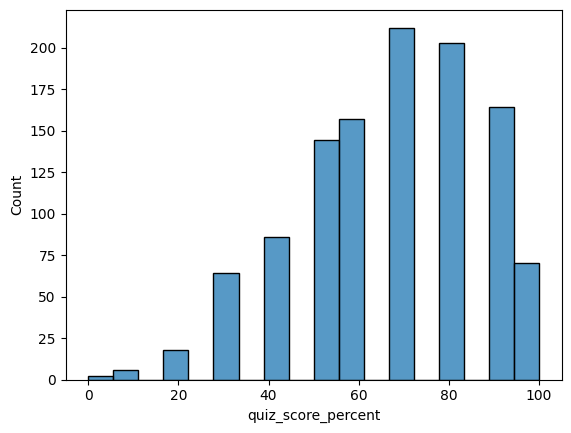

In [8]:
sns.histplot(quiz_data['quiz_score_percent'])

In [9]:
# Ensure all students have taken all modules
check = quiz_data.groupby('student_id')['module_id'].unique().reset_index()
assert all(sorted(i) == sorted(list(subtopics.keys())) for i in check['module_id']), "mismatch in module_id"

# Ensure all students have taken all quizzes
check = quiz_data.groupby('student_id')['quiz_id'].unique().reset_index()
assert all(len(i)== len(quiz_id_map.keys()) for i in check['quiz_id']), "mismatch in quiz_id"

# Ensure each quiz is about specifically one subtopic
assert all(quiz_data.groupby('quiz_id').agg({'subtopic': 'nunique'})['subtopic'] == 1)

quiz_data.groupby(['student_id','module_id', 'attempt_number', 'quiz_id']).agg({
'quiz_score_percent': list
}).head(50)

quiz_score_percent
student_id module_id attempt_number quiz_id                   
S01        DAVA      1              QZ01                  [40]
                                    QZ02                 [100]
                                    QZ03                  [90]
                                    QZ04                  [30]
                     2              QZ01                  [30]
                                    QZ04                  [30]
                     3              QZ01                  [60]
                                    QZ04                  [60]
           DSES      1              QZ10                  [90]
                                    QZ11                  [50]
                                    QZ12                  [90]
                                    QZ13                  [70]
                                    QZ14                  [70]
                                    QZ15                  [70]
                                    QZ16                  [60]
                     2              QZ11                  [70]
                                    QZ16                  [70]
           DWBI      1              QZ17                  [90]
                                    QZ18                  [70]
                                    QZ19                  [10]
                                    QZ20                  [90]
                     2              QZ19                  [30]
                     3              QZ19                  [20]
           LOMA      1              QZ05                  [70]
                                    QZ06                  [70]
                                    QZ07                  [60]
                                    QZ08                  [50]
                                    QZ09                  [90]
                     2              QZ07                  [80]
                                    QZ08                  [70]
S02        DAVA      1              QZ01                  [50]
                                    QZ02                  [50]
                                    QZ03                  [60]
                                    QZ04                  [90]
           DSES      1              QZ10                  [90]
                                    QZ11                  [80]
                                    QZ12                  [60]
                                    QZ13                  [40]
                                    QZ14                  [80]
                                    QZ15                 [100]
                                    QZ16                  [40]
           DWBI      1              QZ17                 [100]
                                    QZ18                 [100]
                                    QZ19                  [80]
                                    QZ20                  [40]
           LOMA      1              QZ05                  [90]
                                    QZ06                  [80]
                                    QZ07                 [100]
                                    QZ08                  [40]
                                    QZ09                  [30]

## quiz_questions table

In [10]:
print(quiz_data['quiz_id'].nunique())


20


In [11]:
# prep AI generation
from openai import OpenAI
from dotenv import load_dotenv
import os
from google import genai
from google.genai import types
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import random

# READ IF QUIZ_QUESTIONS_BANK EXISTS, ELSE GENERATE DATA FROM CHATGPT
if os.path.exists("quiz_question_bank.csv"):
    quiz_question_bank = pd.read_csv("quiz_question_bank.csv")
    print(quiz_question_bank.info())
    
else:
 
    # Load in API keys for OpenAI and Google Gemini 
    # Load in securely from environment variables
    load_dotenv()
    api_key = os.getenv("OPENAI_API_KEY")
    gemini_key = os.getenv("GEMINI_API_KEY")

    def create_chat_completion(prompt: str, model: str = "default", temperature: float = None):
        """Generate a chat response with the chosen model (default gpt‑4o‑mini)."""

        # Use mini model by default, use full GPT 4.1 model if "normal" is specified
        if model == "normal":
            model = f"gpt-4.1-2025-04-14"
        elif model == "mini":
            model = f"gpt-4.1-mini-2025-04-14"
        elif model == "nano":
            model = f"gpt-4.1-nano-2025-04-14"
        else:
            model = "gpt-4o-mini"

        try:
            client = OpenAI(api_key=api_key)
            
            if temperature is None:
                response = client.responses.create(
                    model=model,
                    input=prompt
                )
            else:
                response = client.responses.create(
                    model=model,
                    input=prompt,
                    temperature=temperature
                )

            return response.output[0].content[0].text, "Success"
        except Exception as e:
            return str(e), "Error"


    def run_model(prompt, model: str = "mini", temperature: float = None):
        """
        Method to allow us to easily switch between ChatGPT and Gemini without 
        having to do code refactoring.
        """

        if temperature is None: # default case where temperature is not specified
            result, status = create_chat_completion(prompt, model=model)
        else:
            result, status = create_chat_completion(prompt, model=model, temperature=temperature)

        return result, status


    def generate_single_question(quiz_id: str, module_name: str, qnum: int, subtopic: str):
        prompt = (
            f"You are creating question QN{qnum} for a quiz on the topic \"{module_name}\".\n"
            f"Each topic has multiple sub-topics. Ensure that the question is somewhat related to this subtopic: {subtopic}.\n"
            "Ensure your responses are strictly in the English language only. All questions should be clear and concise, and under 25 words long.\n"
            "Try to be as creative as possible in creating a question that is both challenging and engaging. DO NOT USE COMMONLY ASKED QUESTIONS AS IT'S TOO EASY AND REPETITIVE. DO NOT REPEAT QUESTIONS. \n"
            "Output EXACTLY ONE QUESTION IN THIS FORMAT:\n"
            "<question text>"
        )
        # temperature = 2 gives more variation in output, but need to check if model output is stable
        # else temperature = 1.5 is generally very stable
        text, status = run_model(prompt, model='mini', temperature=1.5)
        if status != "Success":
            raise RuntimeError(f"API error for {quiz_id} QN{qnum}: {text}")
        question_text = text.strip()
        return {"quiz_id": quiz_id, "question_text": question_text, "subtopic": subtopic}

    # Assume quiz_data is a DataFrame already loaded in your environment
    # quiz_data = pd.read_csv("quiz_data.csv")

    all_questions = []
    global_counter = 1

    # Batch by module_name to avoid race conditions
    # use multiparallel network requests so the code don't take a billion years to load
    for module_name, group in quiz_data.groupby("module_name"):
        tasks = []
        for quiz_id in group["quiz_id"].unique():
            # one batch of requests = 10 requests
            # send 10 questions at one time
            for qnum in range(1, 11): 
                tasks.append((quiz_id, module_name, qnum, group.loc[group['quiz_id'] == quiz_id, 'subtopic'].iloc[0]))
        with ThreadPoolExecutor(max_workers=10) as executor:
            futures = {
                executor.submit(generate_single_question, quiz_id, module_name, qnum, subtopic): (quiz_id, qnum, subtopic)
                for quiz_id, module_name, qnum, subtopic in tasks
            }
            for fut in tqdm(as_completed(futures), total=len(futures), desc=f"Generating for {module_name}"):
                quiz_id, qnum, subtopic = futures[fut]
                try:
                    result = fut.result()
                    result["question_id"] = f"QN{global_counter}"
                    global_counter += 1
                    all_questions.append(result)
                except Exception as e:
                    print(f"Error for {quiz_id} QN{qnum}: {e}")

    # Build the final quiz_question_bank DataFrame
    quiz_question_bank = pd.DataFrame(all_questions, columns=["question_id", "quiz_id", "question_text", "subtopic"])

    # Preview first 20 questions
    print(quiz_question_bank.head(20))

    # Save to CSV
    quiz_question_bank.to_csv("quiz_question_bank.csv", index=False)
    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   question_id    200 non-null    object
 1   quiz_id        200 non-null    object
 2   question_text  200 non-null    object
 3   subtopic       200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB
None


In [12]:
# Check that there's no response degeneration in the question text, which can be a problem at very high temperatures
print(quiz_question_bank['question_text'].nunique())
print(quiz_question_bank['question_text'].unique())

199
['How does Python’s pandas library handle missing data during preprocessing in a typical data science workflow?'
 "How can Pandas' groupby function transform and summarize time-series data for detecting seasonal trends in Python?"
 "How does Python's pandas library simplify handling missing data in large datasets during exploratory analysis?"
 "How does Python's versatility influence the choice of libraries when performing exploratory data analysis in data science?"
 'How does Python’s Pandas library simplify handling missing data during exploratory data analysis in Data Science?'
 'Which Python library combines data manipulation and visualization, enabling exploratory data analysis in a seamless workflow?'
 'How can Python’s list comprehensions enhance the efficiency of data cleaning steps in a data science pipeline?'
 "How can you leverage Python's List Comprehensions to efficiently filter and transform large datasets in an introductory data science project?"
 'How can Python’s S

In [13]:
quiz_question_bank.groupby('quiz_id').agg({'subtopic': 'unique'}).reset_index()

,quiz_id,subtopic
0,QZ01,[Intro to Data Analytics]
1,QZ02,[Exploratory Data Analysis]
2,QZ03,[Data Preparation]
3,QZ04,[Predictive Analytics]
4,QZ05,[Logic]
5,QZ06,[Function]
6,QZ07,[Sequence & Recursion]
7,QZ08,[Graphs]
8,QZ09,[Probability]
9,QZ10,[Introduction to Data Science in Python]


In [14]:
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_colwidth', 150)
quiz_question_bank.sort_values('quiz_id', ascending=True, inplace=True)

quiz_question_bank.reset_index(drop=True, inplace=True)
quiz_question_bank['question_id'] = "QN" + (quiz_question_bank.index + 1).astype(str)
quiz_question_bank

,question_id,quiz_id,question_text,subtopic
0,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics
1,QN2,QZ01,How can outlier detection in data analytics enhance the accuracy of predictive models before visualization begins?,Intro to Data Analytics
2,QN3,QZ01,How can data anomalies discovered during exploratory analysis impact the conclusions drawn in data analytics projects?,Intro to Data Analytics
3,QN4,QZ01,How does exploratory data analysis (EDA) enhance the decision-making process before applying predictive models?,Intro to Data Analytics
4,QN5,QZ01,How can data visualization enhance the interpretability of patterns in raw datasets during the initial stages of data analytics?,Intro to Data Analytics
...,...,...,...,...
195,QN196,QZ20,How does a galaxy schema differ structurally and functionally from a star schema in data warehousing?,DW Model: DW Schemas
196,QN197,QZ20,How do snowflake schemas impact query performance and complexity compared to star schemas in data warehousing?,DW Model: DW Schemas
197,QN198,QZ20,How does a Galaxy Schema differ from a Star Schema in combining multiple fact tables for complex business queries?,DW Model: DW Schemas
198,QN199,QZ20,How does a snowflake schema uniquely optimize query performance compared to a star schema in complex dimensional hierarchies?,DW Model: DW Schemas


## quiz_df table

In [15]:
quiz_df = pd.merge(left=quiz_question_bank, right=quiz_data, on='quiz_id', how='outer').sort_values(by=['question_id', 'quiz_id', 'student_id'])
quiz_df.drop(columns=['subtopic_y'], inplace=True)
quiz_df.rename(columns={'subtopic_x': 'subtopic'}, inplace=True)

pd.set_option('display.max_rows', 100)
quiz_df.groupby(['quiz_id', 'question_id', 'student_id'])['attempt_number'].apply(list)

quiz_id  question_id  student_id
QZ01     QN1          S01           [1, 2, 3]
                      S02                 [1]
                      S03              [1, 2]
                      S04                 [1]
                      S05                 [1]
                                      ...    
QZ20     QN200        S46                 [1]
                      S47                 [1]
                      S48                 [1]
                      S49              [1, 2]
                      S50                 [1]
Name: attempt_number, Length: 10000, dtype: object

In [16]:
quiz_df.sort_values(by=['quiz_id', 'question_id', 'student_id']).head(20)

,question_id,quiz_id,question_text,subtopic,student_id,module_id,module_name,attempt_number,quiz_score_percent,quiz_timestamp,quiz_duration_secs
0,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,1,40,2024-01-13 10:00:48,521
1,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,2,30,2024-02-22 19:51:22,1549
2,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,3,60,2024-01-16 03:24:40,1736
3,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S02,DAVA,Data Visualization & Analytics,1,50,2024-07-23 13:10:47,634
4,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S03,DAVA,Data Visualization & Analytics,1,60,2024-09-29 04:34:43,1572
5,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S03,DAVA,Data Visualization & Analytics,2,70,2024-10-08 06:00:43,967
6,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S04,DAVA,Data Visualization & Analytics,1,70,2024-09-28 05:43:55,644
7,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S05,DAVA,Data Visualization & Analytics,1,70,2024-02-24 20:08:32,1529
8,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S06,DAVA,Data Visualization & Analytics,1,80,2024-12-25 03:56:08,2125
9,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S07,DAVA,Data Visualization & Analytics,1,90,2024-05-31 20:11:07,2131


In [17]:
quiz_df = quiz_df.sort_values(
    by=['quiz_id', 'student_id', 'question_id'],
    ascending=[True, True, True]
).reset_index(drop=True)

# 2. Reassign attempt_number per quiz/student group
quiz_df['attempt_number'] = (
    quiz_df
      .groupby(['quiz_id', 'student_id', 'question_id'])
      .cumcount()
      .add(1)   # makes it 1, 2, 3, …
)

# Quick check:
quiz_df.sort_values(by=['quiz_id','question_id','student_id']).head(50)

,question_id,quiz_id,question_text,subtopic,student_id,module_id,module_name,attempt_number,quiz_score_percent,quiz_timestamp,quiz_duration_secs
0,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,1,40,2024-01-13 10:00:48,521
1,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,2,30,2024-02-22 19:51:22,1549
2,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,3,60,2024-01-16 03:24:40,1736
30,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S02,DAVA,Data Visualization & Analytics,1,50,2024-07-23 13:10:47,634
40,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S03,DAVA,Data Visualization & Analytics,1,60,2024-09-29 04:34:43,1572
41,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S03,DAVA,Data Visualization & Analytics,2,70,2024-10-08 06:00:43,967
60,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S04,DAVA,Data Visualization & Analytics,1,70,2024-09-28 05:43:55,644
70,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S05,DAVA,Data Visualization & Analytics,1,70,2024-02-24 20:08:32,1529
80,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S06,DAVA,Data Visualization & Analytics,1,80,2024-12-25 03:56:08,2125
90,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S07,DAVA,Data Visualization & Analytics,1,90,2024-05-31 20:11:07,2131


In [18]:
quiz_df.sort_values(by=['quiz_id','student_id']).head(50)

,question_id,quiz_id,question_text,subtopic,student_id,module_id,module_name,attempt_number,quiz_score_percent,quiz_timestamp,quiz_duration_secs
0,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,1,40,2024-01-13 10:00:48,521
1,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,2,30,2024-02-22 19:51:22,1549
2,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,3,60,2024-01-16 03:24:40,1736
3,QN10,QZ01,How can anomaly detection in datasets improve decision-making during the initial stages of data analytics?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,1,40,2024-01-13 10:00:48,521
4,QN10,QZ01,How can anomaly detection in datasets improve decision-making during the initial stages of data analytics?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,2,30,2024-02-22 19:51:22,1549
5,QN10,QZ01,How can anomaly detection in datasets improve decision-making during the initial stages of data analytics?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,3,60,2024-01-16 03:24:40,1736
6,QN2,QZ01,How can outlier detection in data analytics enhance the accuracy of predictive models before visualization begins?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,1,40,2024-01-13 10:00:48,521
7,QN2,QZ01,How can outlier detection in data analytics enhance the accuracy of predictive models before visualization begins?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,2,30,2024-02-22 19:51:22,1549
8,QN2,QZ01,How can outlier detection in data analytics enhance the accuracy of predictive models before visualization begins?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,3,60,2024-01-16 03:24:40,1736
9,QN3,QZ01,How can data anomalies discovered during exploratory analysis impact the conclusions drawn in data analytics projects?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,1,40,2024-01-13 10:00:48,521


In [19]:
def assign_correct_flags(group):
    # Calculate how many questions should be correct (percent of 10)
    n_correct = int(group['quiz_score_percent'].iloc[0] * len(group) / 100)
    
    group = group.copy()
    group['is_correct'] = 0
    
    # Randomly pick which questions are correct
    correct_idxs = group.sample(n=n_correct, random_state=42).index
    group.loc[correct_idxs, 'is_correct'] = 1
    
    return group

# Now include attempt_number in the groupby:
quiz_df = (
    quiz_df
      .groupby(['quiz_id','student_id','attempt_number'], group_keys=False)
      .apply(assign_correct_flags)
      .reset_index(drop=True)
)

# Sanity check per quiz/student/attempt:
check = (
    quiz_df
      .groupby(['quiz_id','student_id','attempt_number'])['is_correct']
      .sum()
      .reset_index(name='n_correct_assigned')
)

# Bring in the expected count from quiz_score_percent:
check['n_expected'] = (
    check
      .merge(
         quiz_df[['quiz_id','student_id','attempt_number','quiz_score_percent']]
           .drop_duplicates(),
         on=['quiz_id','student_id','attempt_number']
       )['quiz_score_percent']
      .mul(10)
      .div(100)
      .round()
      .astype(int)
)

assert all(check['n_correct_assigned'] == check['n_expected'])
 

/var/folders/d_/bpwmn9vn2fz_kczs0cbm5m7m0000gn/T/ipykernel_9573/2901178806.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_correct_flags)


In [20]:
# sanity check
sanity = quiz_df.groupby(['student_id', 'quiz_id', 'attempt_number']).agg(
          total_correct=('is_correct', 'sum'),
          quiz_score_percent=('quiz_score_percent', 'first')
      ).reset_index()

sanity['total_correct'] = sanity['total_correct'].astype(int)
sanity['expected_correct'] = sanity['quiz_score_percent'] * 10 // 100

assert all(sanity['total_correct'] == sanity['expected_correct']), "error"

## test_data table

In [21]:
n_students   = 50
modules      = subtopics.keys()
tests        = [f"TS{i:02d}" for i in range(1, 2*len(modules)+1)]
start_date   = datetime(2024, 1, 1)
end_date     = datetime(2024, 12, 31)

module_names = {
    'DAVA': 'Data Visualization & Analytics',
    'DSES': 'Data Science Essentials',
    'DWBI': 'Data Warehousing & Business Intelligence',
    'LOMA': 'Logic & Mathematics'
}
module_to_tests = {
    mod: [tests[2*(i-1)], tests[2*(i-1)+1]]
    for i, mod in enumerate(modules, start=1)
}

PROFILE = {
    'A': dict(DAVA=85, DSES=85, DWBI=65, LOMA=65),   # Data / Analytics stars
    'B': dict(DAVA=65, DSES=65, DWBI=85, LOMA=85),   # BI / Logic stars
    'C': dict(DAVA=58, DSES=54, DWBI=56, LOMA=60)    # Struggling students
}
SIGMA = 8      # std-dev of individual scores inside each module
CLUSTERS = list(PROFILE.keys())

def assign_cluster(idx: int) -> str:
    """Round-robin: S01→A, S02→B, S03→C, S04→A, …"""
    return CLUSTERS[(idx-1) % len(CLUSTERS)]

def noisy_score(mean: float, sigma: float = SIGMA) -> float:
    """Draw N(mean, sigma), clamp [0,100], round to .5"""
    return round(min(100, max(0, np.random.normal(mean, sigma))) / 4) * 4 # round to nearest multiple of 4

def random_date(start: datetime, end: datetime) -> datetime:
    delta = end - start
    return start + timedelta(days=random.randint(0, delta.days),
                             seconds=random.randint(0, 86_399))

# ------------------------------------------------------------------
# 2.  BUILD ROWS
# ------------------------------------------------------------------
rows = []
for i in range(1, n_students+1):
    sid = f"S{i:02d}"
    clus = assign_cluster(i)
    mu_profile = PROFILE[clus]

    for mod in modules:
        mu = mu_profile[mod]
        for tid in module_to_tests[mod]:
            rows.append({
                "student_id"        : sid,
                "cluster"           : clus,                 # keep for QA, drop before ML
                "test_id"           : tid,
                "module_id"         : mod,
                "module_name"       : module_names[mod],
                "test_score_percent": noisy_score(mu), # round to nearest multiple of 4
                "test_timestamp"    : random_date(start_date, end_date)
            })

test_data = pd.DataFrame(rows)

# ------------------------------------------------------------------
# 3.  QUICK sanity-check pivot  (comment out in prod)
# ------------------------------------------------------------------
pivot = (test_data
         .pivot_table(index="student_id", columns="test_id",
                      values="test_score_percent", aggfunc="mean")
         .assign(cluster=test_data.groupby("student_id")["cluster"].unique()))

# after checking the pivot, drop cluster column
test_data = test_data.drop(columns=["cluster"])

pivot

test_id,TS01,TS02,TS03,TS04,TS05,TS06,TS07,TS08,cluster
student_id,,,,,,,,,
S01,76.0,100.0,56.0,72.0,84.0,88.0,60.0,64.0,[A]
S02,64.0,56.0,92.0,80.0,64.0,56.0,64.0,84.0,[B]
S03,76.0,64.0,60.0,56.0,56.0,60.0,48.0,64.0,[C]
S04,92.0,92.0,68.0,64.0,92.0,88.0,64.0,60.0,[A]
S05,64.0,76.0,76.0,72.0,68.0,64.0,88.0,88.0,[B]
S06,56.0,68.0,48.0,52.0,52.0,40.0,56.0,68.0,[C]
S07,84.0,88.0,56.0,60.0,80.0,84.0,76.0,68.0,[A]
S08,56.0,68.0,88.0,96.0,76.0,56.0,80.0,76.0,[B]
S09,56.0,60.0,68.0,60.0,52.0,56.0,48.0,72.0,[C]


In [22]:
test_data

,student_id,test_id,module_id,module_name,test_score_percent,test_timestamp
0,S01,TS01,DAVA,Data Visualization & Analytics,76,2024-10-17 20:31:13
1,S01,TS02,DAVA,Data Visualization & Analytics,100,2024-03-13 20:30:07
2,S01,TS03,LOMA,Logic & Mathematics,56,2024-04-06 17:55:17
3,S01,TS04,LOMA,Logic & Mathematics,72,2024-10-04 11:15:08
4,S01,TS05,DSES,Data Science Essentials,84,2024-03-30 17:51:22
...,...,...,...,...,...,...
395,S50,TS04,LOMA,Logic & Mathematics,88,2024-09-15 17:05:10
396,S50,TS05,DSES,Data Science Essentials,68,2024-09-10 06:01:19
397,S50,TS06,DSES,Data Science Essentials,72,2024-02-08 17:54:01
398,S50,TS07,DWBI,Data Warehousing & Business Intelligence,84,2024-06-13 08:46:14


In [23]:
test_id_check = test_data.groupby('student_id')['test_id'].agg(list).values

# Check all students take all tests
assert all(sorted(list(set(i))) == tests for i in test_id_check), "Not all students take all specified tests"

In [24]:
module_id_check = test_data.groupby('student_id')['module_id'].agg(list).values
module_id_check

# Check all students take all modules
assert all(sorted(list(set(i))) == sorted(list(set(modules))) for i in module_id_check), "Not all students take all specified modules"

In [25]:
# Check length of test_data matches n_students * n_tests
assert len(test_data) == n_students * len(tests)

## Check each module has preciesly two tests
assert all(test_data.groupby(['module_id'])['test_id'].nunique() == 2)

In [26]:
# Check if the test_score_percent is between 0 and 100
assert test_data['test_score_percent'].between(0, 100).all(), "test_score_percent is not between 0 and 100"

# Check if the test_score_percent makes sense for number of questions
# I.e. if 25 questions, then test_score_percent needs to be in multiples of 4 (100/25, no partial marks)
n_questions_per_test = 25
assert all(test_data['test_score_percent'].mod(int(100/n_questions_per_test)) == 0), "test_score_percent is not a multiple of 4"

In [27]:
test_data.groupby(['test_id', 'student_id'])['test_score_percent'].sum()

test_id  student_id
TS01     S01           76
         S02           64
         S03           76
         S04           92
         S05           64
                       ..
TS08     S46           84
         S47           92
         S48           56
         S49           72
         S50           80
Name: test_score_percent, Length: 400, dtype: int64

In [28]:
test_data

,student_id,test_id,module_id,module_name,test_score_percent,test_timestamp
0,S01,TS01,DAVA,Data Visualization & Analytics,76,2024-10-17 20:31:13
1,S01,TS02,DAVA,Data Visualization & Analytics,100,2024-03-13 20:30:07
2,S01,TS03,LOMA,Logic & Mathematics,56,2024-04-06 17:55:17
3,S01,TS04,LOMA,Logic & Mathematics,72,2024-10-04 11:15:08
4,S01,TS05,DSES,Data Science Essentials,84,2024-03-30 17:51:22
...,...,...,...,...,...,...
395,S50,TS04,LOMA,Logic & Mathematics,88,2024-09-15 17:05:10
396,S50,TS05,DSES,Data Science Essentials,68,2024-09-10 06:01:19
397,S50,TS06,DSES,Data Science Essentials,72,2024-02-08 17:54:01
398,S50,TS07,DWBI,Data Warehousing & Business Intelligence,84,2024-06-13 08:46:14


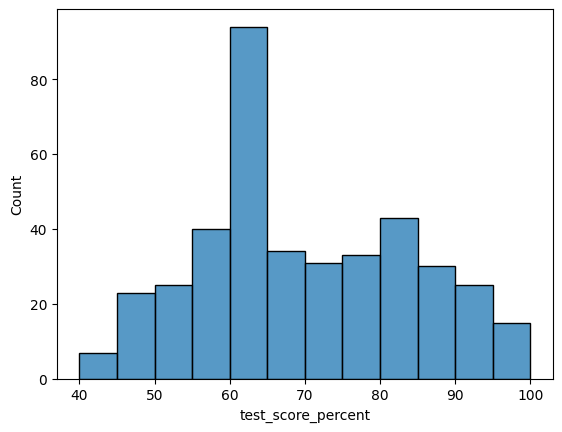

In [29]:

sns.histplot(test_data['test_score_percent'])
plt.show()

## Test_question_bank

In [30]:
print(test_data['test_id'].unique())

['TS01' 'TS02' 'TS03' 'TS04' 'TS05' 'TS06' 'TS07' 'TS08']


In [31]:
def create_chat_completion(prompt, model="default", temperature=None):
    """Generate a chat response with the chosen model (default gpt‑4o‑mini)."""

    # Use mini model by default, use full GPT 4.1 model if "normal" is specified
    if model == "normal":
        model = "gpt-4.1-2025-04-14"
    elif model == "mini":
        model = "gpt-4.1-mini-2025-04-14"
    elif model == "nano":
        model = "gpt-4.1-nano-2025-04-14"
    else:
        model = "gpt-4o-mini"

    try:
        client = OpenAI(api_key=api_key)
        
        if temperature is None:
            response = client.responses.create(
                model=model,
                input=prompt
            )
        else:
            response = client.responses.create(
                model=model,
                input=prompt,
                temperature=temperature
            )

        return response.output[0].content[0].text, "Success"
    except Exception as e:
        return str(e), "Error"


def run_model(prompt, model="mini", temperature=None):
    """
    Method to allow us to easily switch between ChatGPT and Gemini without 
    having to do code refactoring.
    """

    if temperature is None:
        result, status = create_chat_completion(prompt, model=model)
    else:
        result, status = create_chat_completion(prompt, model=model, temperature=temperature)

    return result, status


def generate_single_question(test_id, module_name, subtopic, q_index, existing):
    """Generate a single unique question for a given sub‑topic."""
    prompt = (
        f"You are creating exam question #{q_index} for the quiz on module \"{module_name}\".\n"
        f"Sub‑topic focus: \"{subtopic}\".\n"
        "Ensure your responses are strictly in the English language only. All questions should be clear and concise, and under 25 words long.\n"
        "Try to be as creative as possible in creating a question that is both challenging and engaging. DO NOT USE COMMONLY ASKED QUESTIONS AS IT'S TOO EASY AND REPETITIVE. DO NOT REPEAT QUESTIONS. \n"
        "Output EXACTLY ONE QUESTION IN THIS FORMAT:\n"
        "<question text>"
    )

    for attempt in range(QUESTION_RETRY_LIMIT + 1):
        text, status = run_model(prompt, model="mini", temperature=1.5)
        if status != "Success":
            raise RuntimeError(f"API error: {text}")
        question = text.strip().replace("\n", " ")
        if question not in existing:
            existing.add(question)
            return {
                "test_id": test_id,
                "subtopic": subtopic,
                "question_text": question,
            }
    # Fallback – even after retries we got duplicates
    raise ValueError(f"Duplicate question could not be resolved for {module_name}/{subtopic}")


QUESTION_RETRY_LIMIT = 3        # unchanged
QUESTIONS_PER_TEST   = 25       # ← one constant, used everywhere

def build_question_bank(test_data, max_workers=10):
    """
    Generate a question bank where *every* test_id contains exactly
    QUESTIONS_PER_TEST questions, split as evenly as possible over
    that module's sub-topics.
    """
    all_questions       = []
    question_text_set   = set()
    global_counter      = 1

    for module_id, group in test_data.groupby("module_id"):
        subs = subtopics[module_id]                 # list of sub-topics
        n_subs = len(subs)

        # --- figure out the quota for each sub-topic -----------------
        base_q = QUESTIONS_PER_TEST // n_subs         # min per sub-topic
        extra  = QUESTIONS_PER_TEST % n_subs          # first 'extra' subs get +1

        # e.g. 25 questions & 4 sub-topics  -> [7,6,6,6]
        quota = [base_q + (1 if i < extra else 0) for i in range(n_subs)]

        for test_id in group["test_id"].unique():
            tasks = []          # each item: (test_id, module, sub, q_index)
            q_idx = 1           # question # within this test

            for sub, q_count in zip(subs, quota):
                for _ in range(q_count):
                    tasks.append((test_id, module_names[module_id], sub, q_idx))
                    q_idx += 1
            # --------------------------------------------------------------

            with ThreadPoolExecutor(max_workers=max_workers) as executor:
                futures = {
                    executor.submit(
                        generate_single_question,
                        tid, mod_name, sub, qi, question_text_set
                    ): (tid, qi)
                    for tid, mod_name, sub, qi in tasks
                }
                for fut in tqdm(
                    as_completed(futures),
                    total=len(futures),
                    desc=f"Generating for {module_id} / {test_id}"
                ):
                    try:
                        result = fut.result()
                        result["question_id"] = f"QN{global_counter}"
                        global_counter += 1
                        all_questions.append(result)
                    except Exception as e:
                        print(f"Error generating question: {e}")

    return pd.DataFrame(
        all_questions,
        columns=["question_id", "test_id", "subtopic", "question_text"],
    )

# READ IF QUIZ_QUESTIONS_BANK EXISTS, ELSE DON'T RUN THIS CELL
import os
from dotenv import load_dotenv
if os.path.exists("test_question_bank.csv"):
    test_question_bank = pd.read_csv("test_question_bank.csv")
    test_question_bank.info()

else:
    # Load in API keys for OpenAI and Google Gemini 
    # Load in securely from environment variables
    load_dotenv()
    global api_key
    api_key = os.getenv("OPENAI_API_KEY")

    test_question_bank = build_question_bank(test_data)
    test_question_bank.to_csv("test_question_bank.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   question_id    200 non-null    object
 1   test_id        200 non-null    object
 2   subtopic       200 non-null    object
 3   question_text  200 non-null    object
dtypes: object(4)
memory usage: 6.4+ KB


In [32]:
print(test_question_bank['question_text'].nunique())
test_question_bank

200


,question_id,test_id,subtopic,question_text
0,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics transform raw data into actionable insights for predictive decision-making?
1,QN2,TS01,Intro to Data Analytics,How can anomaly detection in data analytics uncover insights that traditional mean-based analysis might overlook?
2,QN3,TS01,Intro to Data Analytics,"How can correlation mislead data interpretation, and what approach helps confirm true causal relationships in analytics?"
3,QN4,TS01,Intro to Data Analytics,How can anomaly detection enhance decision-making in real-time data analytics for financial forecasting?
4,QN5,TS01,Intro to Data Analytics,How can data triangulation enhance the validity of insights in an introductory data analytics project?
...,...,...,...,...
195,QN196,TS04,Graphs,"In a simple connected graph, what's the minimum number of edges to remove to disconnect all cycles and leave a spanning tree?"
196,QN197,TS04,Probability,"If two independent events each have a 60% chance of occurring, what is the probability that exactly one of them occurs?"
197,QN198,TS04,Probability,"In a sealed box of 15 coins, 3 are double-headed. If one coin flipped shows heads 4 times, what is the probability it's double-headed?"
198,QN199,TS04,Probability,"If three dice are rolled, what's the probability that the sum is a prime number and at least one die shows a 4?"


In [33]:
test_question_bank['question_text'].nunique()

200

## test_df table

In [34]:
test_df = pd.merge(left=test_question_bank, right=test_data, on='test_id', how='outer').sort_values(by=['test_id', 'question_id', 'student_id'])

pd.set_option('display.max_rows', 100)
test_df

,question_id,test_id,subtopic,question_text,student_id,module_id,module_name,test_score_percent,test_timestamp
0,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics transform raw data into actionable insights for predictive decision-making?,S01,DAVA,Data Visualization & Analytics,76,2024-10-17 20:31:13
1,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics transform raw data into actionable insights for predictive decision-making?,S02,DAVA,Data Visualization & Analytics,64,2024-01-11 19:10:02
2,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics transform raw data into actionable insights for predictive decision-making?,S03,DAVA,Data Visualization & Analytics,76,2024-02-26 19:09:42
3,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics transform raw data into actionable insights for predictive decision-making?,S04,DAVA,Data Visualization & Analytics,92,2024-11-28 11:33:06
4,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics transform raw data into actionable insights for predictive decision-making?,S05,DAVA,Data Visualization & Analytics,64,2024-01-01 20:51:22
...,...,...,...,...,...,...,...,...,...
9995,QN150,TS08,DW Model: DW Schemas,"How does a snowflake schema optimize data storage compared to a star schema, and what is its impact on query complexity?",S46,DWBI,Data Warehousing & Business Intelligence,84,2024-03-26 04:06:58
9996,QN150,TS08,DW Model: DW Schemas,"How does a snowflake schema optimize data storage compared to a star schema, and what is its impact on query complexity?",S47,DWBI,Data Warehousing & Business Intelligence,92,2024-11-09 01:02:57
9997,QN150,TS08,DW Model: DW Schemas,"How does a snowflake schema optimize data storage compared to a star schema, and what is its impact on query complexity?",S48,DWBI,Data Warehousing & Business Intelligence,56,2024-10-22 20:34:17
9998,QN150,TS08,DW Model: DW Schemas,"How does a snowflake schema optimize data storage compared to a star schema, and what is its impact on query complexity?",S49,DWBI,Data Warehousing & Business Intelligence,72,2024-07-16 05:24:44


In [35]:
def assign_correct_flags(group):
    """
    For a single (test_id, student_id) block:
    - compute how many questions should be flagged correct
      based on test_score_percent
    - randomly mark exactly that many rows as is_correct = 1
    """
    # total questions in this block
    n_q = len(group)

    # desired number correct
    n_correct = int(group['test_score_percent'].iloc[0] * n_q / 100)

    group = group.copy()
    group['is_correct'] = 0

    if n_correct > 0:                      # avoid ValueError when n_correct == 0
        correct_idx = group.sample(
            n=n_correct, random_state=42   # reproducible choice
        ).index
        group.loc[correct_idx, 'is_correct'] = 1

    return group

# ---------- main ----------
test_df = (
    test_df
      .groupby(['test_id', 'student_id'], group_keys=False)
      .apply(assign_correct_flags)
      .reset_index(drop=True)
)

# preview
print(test_df.sort_values(['test_id', 'student_id', 'question_id']).head(20))

    question_id test_id                   subtopic  \
0           QN1    TS01    Intro to Data Analytics   
50         QN10    TS01  Exploratory Data Analysis   
100        QN11    TS01           Data Preparation   
150        QN12    TS01           Data Preparation   
200        QN13    TS01  Exploratory Data Analysis   
250        QN14    TS01           Data Preparation   
300        QN15    TS01           Data Preparation   
350        QN16    TS01  Exploratory Data Analysis   
400        QN17    TS01           Data Preparation   
450        QN18    TS01       Predictive Analytics   
500        QN19    TS01       Predictive Analytics   
550         QN2    TS01    Intro to Data Analytics   
600        QN20    TS01       Predictive Analytics   
650        QN21    TS01       Predictive Analytics   
700        QN22    TS01       Predictive Analytics   
750        QN23    TS01       Predictive Analytics   
800        QN24    TS01           Data Preparation   
850        QN25    TS01  Exp

/var/folders/d_/bpwmn9vn2fz_kczs0cbm5m7m0000gn/T/ipykernel_9573/2960862296.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_correct_flags)


#### Use cases of subtopics

In [36]:
subtopic_agg = test_df.groupby(['student_id', 'module_id', 'subtopic']).agg({'is_correct': 'sum'})
subtopic_agg

is_correct
student_id module_id subtopic                                                   
S01        DAVA      Data Preparation                                         11
                     Exploratory Data Analysis                                10
                     Intro to Data Analytics                                  13
                     Predictive Analytics                                     10
           DSES      Cluster Analysis in Python (K-Means Clustering)           6
...                                                                          ...
S50        LOMA      Function                                                  8
                     Graphs                                                    9
                     Logic                                                    10
                     Probability                                               8
                     Sequence & Recursion                                     10

[1000 rows x 1 columns]

In [37]:
weak_subtopics = (subtopic_agg.groupby(['student_id', 'module_id', 'subtopic'])['is_correct'].sum().reset_index()
          .query('is_correct <= 6')
          .groupby(['student_id', 'module_id'])['subtopic'].apply(list).reset_index())

weak_subtopics

,student_id,module_id,subtopic
0,S01,DSES,"[Cluster Analysis in Python (K-Means Clustering), Dealing with Missing Data in Python, Introduction to Data Visualisation with Seaborn, Introducti..."
1,S01,DWBI,[DW Model: DW Schemas]
2,S01,LOMA,"[Function, Graphs, Probability, Sequence & Recursion]"
3,S02,DAVA,"[Exploratory Data Analysis, Predictive Analytics]"
4,S02,DSES,"[Cluster Analysis in Python (K-Means Clustering), Data Manipulation in pandas, Dealing with Missing Data in Python, EDA in Python, Introduction to..."
...,...,...,...
142,S49,DSES,"[Cluster Analysis in Python (K-Means Clustering), Dealing with Missing Data in Python, Introduction to Data Visualisation with Seaborn, Introducti..."
143,S49,DWBI,[DW Model: DW Schemas]
144,S49,LOMA,"[Function, Graphs, Probability, Sequence & Recursion]"
145,S50,DAVA,"[Exploratory Data Analysis, Predictive Analytics]"


In [38]:
quiz_df

,question_id,quiz_id,question_text,subtopic,student_id,module_id,module_name,attempt_number,quiz_score_percent,quiz_timestamp,quiz_duration_secs,is_correct
0,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,1,40,2024-01-13 10:00:48,521,1
1,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,2,30,2024-02-22 19:51:22,1549,0
2,QN1,QZ01,How does exploratory data analysis enhance decision-making in data analytics beyond just generating static reports?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,3,60,2024-01-16 03:24:40,1736,1
3,QN10,QZ01,How can anomaly detection in datasets improve decision-making during the initial stages of data analytics?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,1,40,2024-01-13 10:00:48,521,1
4,QN10,QZ01,How can anomaly detection in datasets improve decision-making during the initial stages of data analytics?,Intro to Data Analytics,S01,DAVA,Data Visualization & Analytics,2,30,2024-02-22 19:51:22,1549,1
...,...,...,...,...,...,...,...,...,...,...,...,...
11255,QN196,QZ20,How does a galaxy schema differ structurally and functionally from a star schema in data warehousing?,DW Model: DW Schemas,S50,DWBI,Data Warehousing & Business Intelligence,1,40,2024-01-15 12:48:15,1686,1
11256,QN197,QZ20,How do snowflake schemas impact query performance and complexity compared to star schemas in data warehousing?,DW Model: DW Schemas,S50,DWBI,Data Warehousing & Business Intelligence,1,40,2024-01-15 12:48:15,1686,0
11257,QN198,QZ20,How does a Galaxy Schema differ from a Star Schema in combining multiple fact tables for complex business queries?,DW Model: DW Schemas,S50,DWBI,Data Warehousing & Business Intelligence,1,40,2024-01-15 12:48:15,1686,0
11258,QN199,QZ20,How does a snowflake schema uniquely optimize query performance compared to a star schema in complex dimensional hierarchies?,DW Model: DW Schemas,S50,DWBI,Data Warehousing & Business Intelligence,1,40,2024-01-15 12:48:15,1686,1


In [39]:
test_df

,question_id,test_id,subtopic,question_text,student_id,module_id,module_name,test_score_percent,test_timestamp,is_correct
0,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics transform raw data into actionable insights for predictive decision-making?,S01,DAVA,Data Visualization & Analytics,76,2024-10-17 20:31:13,1
1,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics transform raw data into actionable insights for predictive decision-making?,S02,DAVA,Data Visualization & Analytics,64,2024-01-11 19:10:02,1
2,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics transform raw data into actionable insights for predictive decision-making?,S03,DAVA,Data Visualization & Analytics,76,2024-02-26 19:09:42,1
3,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics transform raw data into actionable insights for predictive decision-making?,S04,DAVA,Data Visualization & Analytics,92,2024-11-28 11:33:06,1
4,QN1,TS01,Intro to Data Analytics,How can anomaly detection in data analytics transform raw data into actionable insights for predictive decision-making?,S05,DAVA,Data Visualization & Analytics,64,2024-01-01 20:51:22,1
...,...,...,...,...,...,...,...,...,...,...
9995,QN150,TS08,DW Model: DW Schemas,"How does a snowflake schema optimize data storage compared to a star schema, and what is its impact on query complexity?",S46,DWBI,Data Warehousing & Business Intelligence,84,2024-03-26 04:06:58,1
9996,QN150,TS08,DW Model: DW Schemas,"How does a snowflake schema optimize data storage compared to a star schema, and what is its impact on query complexity?",S47,DWBI,Data Warehousing & Business Intelligence,92,2024-11-09 01:02:57,1
9997,QN150,TS08,DW Model: DW Schemas,"How does a snowflake schema optimize data storage compared to a star schema, and what is its impact on query complexity?",S48,DWBI,Data Warehousing & Business Intelligence,56,2024-10-22 20:34:17,0
9998,QN150,TS08,DW Model: DW Schemas,"How does a snowflake schema optimize data storage compared to a star schema, and what is its impact on query complexity?",S49,DWBI,Data Warehousing & Business Intelligence,72,2024-07-16 05:24:44,0
